In [ ]:
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import torch.nn as nn
import matplotlib.pyplot as 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, recall_score,precision_score, roc_auc_score
from sklearn.decomposition import PCA

In [48]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [49]:
df = pd.read_csv('smaller_dataset.csv')
testdf = pd.read_csv("combined_sampled.csv")

**New column: Weight**

In [50]:
df["Weight"] = df["Total Fwd Packet"] * df["Total Bwd packets"]

**Fix: Categorical Columns were Mistaken as Strings**

In [51]:
categorical_columns = ["Src IP", 'Dst IP', "Src Port", "Dst Port", "Protocol"]

for col in categorical_columns:
    df[col] = df[col].astype('category')
    testdf[col] = testdf[col].astype('category')


**Create Frequency Distribution**

In [52]:
for col in ['Src IP', 'Dst IP', 'Src Port', 'Dst Port']:
    df[col + '_freq'] = df[col].map(df[col].value_counts())
    testdf[col + '_freq'] = testdf[col].map(testdf[col].value_counts())

**One Hot Encoding of Protocol**

In [53]:
df = pd.get_dummies(df, columns=['Protocol'], prefix='Proto')
testdf["Proto_0"] = False
testdf = pd.get_dummies(testdf, columns=['Protocol'], prefix='Proto')

**Fix DateTime**

In [ ]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'],  format='%d/%m/%Y %I:%M:%S %p')

testdf['Timestamp'] = pd.to_datetime(testdf['Timestamp'])  
#testdf['Timestamp'] = testdf['Timestamp'].dt.strftime('%d/%m/%Y %I:%M:%S %p')  


**Remove high-level attacks that are not derivable from network traffic data**

In [55]:
attacks_to_remove = [
    "spoofing_ARP Spoofing",
    "spoofing_DNS Spoofing",
    "sqlinjection",
    "XSS",
    "Benign&Bruteforce_BruteForce",
    "Uploading_Attack"
]

df = df[~df["Attack_Type"].isin(attacks_to_remove)]
testdf = testdf[~testdf["Attack_Type"].isin(attacks_to_remove)]

**Remove highly correlated features to diminish feature space**

In [ ]:
numeric_columns = df.select_dtypes(include=['number'])

corr_matrix = numeric_columns.corr()

threshold = 0.9

mask = (corr_matrix.abs() >= threshold) & (corr_matrix != 1)

filtered_corr = corr_matrix[mask]


printed_pairs = set()

for col1 in filtered_corr.columns:
    for col2 in filtered_corr.index:
        if not pd.isna(filtered_corr.loc[col2, col1]):
            pair = tuple(sorted([col1, col2]))
            if pair not in printed_pairs:
                printed_pairs.add(pair)
                print(f"Columns: {col1} and {col2} | Correlation: {filtered_corr.loc[col2, col1]:.3f}")

Columns: Flow Duration and Fwd IAT Total | Correlation: 0.994
Columns: Total Fwd Packet and Subflow Fwd Packets | Correlation: 0.986
Columns: Total Length of Fwd Packet and Fwd Act Data Pkts | Correlation: 0.925
Columns: Fwd Packet Length Max and Packet Length Max | Correlation: 0.914
Columns: Bwd Packet Length Max and Bwd Packet Length Std | Correlation: 0.943
Columns: Flow Packets/s and Fwd Packets/s | Correlation: 0.977
Columns: Flow IAT Mean and Fwd IAT Mean | Correlation: 0.925
Columns: Flow IAT Std and Fwd IAT Std | Correlation: 0.918
Columns: Flow IAT Max and Fwd IAT Max | Correlation: 0.989
Columns: Flow IAT Max and Idle Mean | Correlation: 0.981
Columns: Flow IAT Max and Idle Max | Correlation: 1.000
Columns: Flow IAT Max and Idle Min | Correlation: 0.940
Columns: Fwd IAT Max and Idle Mean | Correlation: 0.970
Columns: Fwd IAT Max and Idle Max | Correlation: 0.989
Columns: Fwd IAT Max and Idle Min | Correlation: 0.929
Columns: Bwd IAT Mean and Bwd IAT Max | Correlation: 0.913


In [57]:
columns_to_drop = ["Flow IAT Std",
                   "Bwd Segment Size Avg",
                   "Subflow Fwd Packets",
    'Flow Duration',
    'Subflow Bwd Packets',
    'Fwd Packet Length Max',
    'Fwd Packet Length Min',
    'Flow Packets/s',
    'Flow IAT Min',
    'Flow IAT Max',
    'Bwd IAT Max',
    'Bwd IAT Min',
    'Fwd Header Length',
    'ACK Flag Count',
    'Packet Length Std',
    "Fwd IAT Max",
    "Idle Max",
    "Idle Min",
    "Fwd Packet Length Mean",
    "Bwd Packet Length Max",
    'Average Packet Size',
    'Fwd Segment Size Avg',
    'Fwd IAT Max',
    'Bwd Header Length',
    'Packet Length Mean',
    'CWR Flag Count',
    'Average Packet Size',
    "Flow IAT Mean",
    "Active Max",
    "Bwd Bytes/Bulk Avg",
    'Fwd IAT Mean',
    'Active Mean',
    'Active Std',
    "Fwd Act Data Pkts"
]

df = df.drop(columns=columns_to_drop)
df = df.drop(columns="Label")

testdf = testdf.drop(columns=columns_to_drop)


**Combine Attack Types for Anomaly Detection Preperation**

In [58]:
def create_anomaly_label(row):
    if row['Attack_Type'] == 'Benign&Bruteforce_benign':
        return 'Normal'
    else:
        return 'Attack'

df['Anomaly_Label'] = df.apply(create_anomaly_label, axis=1)
testdf['Anomaly_Label'] = testdf.apply(create_anomaly_label, axis=1)

**Handle Missing and Infinity Values**

In [59]:
null_columns = df.isnull().sum()
null_columns = null_columns[null_columns > 0]
inf_columns = df.columns[(df == np.inf).any() | (df == -np.inf).any()]
df = df.dropna()
df = df[~df.isin([np.inf, -np.inf]).any(axis=1)]
df.replace([np.inf, -np.inf], np.nan, inplace=True)

null_columns = testdf.isnull().sum()
null_columns = null_columns[null_columns > 0]
inf_columns = testdf.columns[(testdf == np.inf).any() | (testdf == -np.inf).any()]
testdf = testdf.dropna()
testdf = testdf[~testdf.isin([np.inf, -np.inf]).any(axis=1)]
testdf.replace([np.inf, -np.inf], np.nan, inplace=True)


***Begin preparation for the model***

In [ ]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dims, activation=nn.ReLU(), dropout_rate=0.0,
                 sequence_length=1, num_layers=1, bidirectional=False):
        super(LSTMAutoencoder, self).__init__()

        self.sequence_length = sequence_length
        self.input_dim = input_dim
        self.hidden_dims = hidden_dims
        self.bottleneck_dim = hidden_dims[-1]
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.directions = 2 if bidirectional else 1
        self.activation = activation

        # Encoder 
        self.encoder_layers = nn.ModuleList()
        prev_dim = input_dim
        for h_dim in hidden_dims:
            self.encoder_layers.append(nn.LSTM(
                input_size=prev_dim,
                hidden_size=h_dim,
                num_layers=1,
                batch_first=True,
                bidirectional=bidirectional
            ))
            prev_dim = h_dim * self.directions

        # Decoder 
        self.decoder_layers = nn.ModuleList()
        reversed_dims = list(reversed(hidden_dims))
        prev_dim = reversed_dims[0] * self.directions  # bottleneck dimension

        # Create decoder layers
        for i in range(len(reversed_dims) - 1):
            next_dim = reversed_dims[i+1]
            self.decoder_layers.append(nn.LSTM(
                input_size=prev_dim,
                hidden_size=next_dim,
                num_layers=1,
                batch_first=True,
                bidirectional=bidirectional
            ))
            prev_dim = next_dim * self.directions

        # Final output layer
        self.output_layer = nn.Linear(hidden_dims[0] * self.directions, input_dim)

        # Dropout layer
        self.dropout = nn.Dropout(dropout_rate) if dropout_rate > 0 else None

    def forward(self, x):
 
        original_shape = x.shape
        if len(x.shape) == 2:
            x = x.unsqueeze(1)  # [batch_size, 1, input_dim]

        batch_size = x.size(0)
        seq_len = x.size(1)

        # Encode
        current_input = x
        for i, encoder in enumerate(self.encoder_layers):
            outputs, (hidden, cell) = encoder(current_input)
            current_input = outputs

            # Apply activation
            if self.activation is not None:
                current_input = self.activation(current_input)

            # Apply dropout except for last layer
            if self.dropout is not None and i < len(self.encoder_layers) - 1:
                current_input = self.dropout(current_input)

        # Get encoded representation (last time step of final encoder output)
        encoded = outputs[:, -1, :]

        # Initialize decoder input with encoded representation
        decoder_input = encoded.unsqueeze(1).repeat(1, seq_len, 1)

        # Decode
        current_input = decoder_input
        for i, decoder in enumerate(self.decoder_layers):
            outputs, _ = decoder(current_input)
            current_input = outputs

            # Apply activation except for last layer
            if self.activation is not None and i < len(self.decoder_layers) - 1:
                current_input = self.activation(current_input)

            # Apply dropout except for last layer
            if self.dropout is not None and i < len(self.decoder_layers) - 1:
                current_input = self.dropout(current_input)

        # Final projection
        reconstructed = self.output_layer(current_input)

        # Return to original shape if needed
        if len(original_shape) == 2:
            reconstructed = reconstructed.squeeze(1)

        return reconstructed, encoded

**Seperate training and test data**

In [ ]:
X = df.select_dtypes(include=['number', 'bool'])
X_datetime = df.select_dtypes(include=['datetime64'])

attack_types = df['Attack_Type']  
y = df['Anomaly_Label'] 
y_binary = (y == "Attack").astype(int)  


df_temp = df.copy()
df_temp['stratify_col'] = df_temp['Attack_Type'] 


df_temp.loc[df_temp['Anomaly_Label'] == 'Normal', 'stratify_col'] = 'Normal'

print("Original Attack Type Distribution:")
print(df_temp['stratify_col'].value_counts())
print(f"\nOriginal Attack/Normal Distribution:")
print(df_temp['Anomaly_Label'].value_counts())


np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Convert datetime to Unix timestamps (seconds)
for col in X_datetime.columns:
    X_datetime[col] = pd.to_datetime(X_datetime[col]).astype('int64') // 10**9


scaler_numerical = StandardScaler()
X_scaled_num = scaler_numerical.fit_transform(X)


scaler_datetime = StandardScaler()
X_scaled_datetime = scaler_datetime.fit_transform(X_datetime)


X_scaled = np.concatenate([X_scaled_num, X_scaled_datetime], axis=1)


pca = PCA(n_components=0.95)  # Retain 95% of variance
X_scaled = pca.fit_transform(X_scaled)


try:
    X_train_full, X_test, y_train_full, y_test, stratify_train, stratify_test = train_test_split(
        X_scaled, y_binary, df_temp['stratify_col'], 
        test_size=0.3, random_state=42, stratify=df_temp['stratify_col']
    )
    
    print("\n=== TRAIN SET DISTRIBUTION ===")
    train_stratify_counts = pd.Series(stratify_train).value_counts()
    print("Attack Type Distribution in Training Set:")
    print(train_stratify_counts)
    print(f"Normal vs Attack in Training Set:")
    print(pd.Series(y_train_full).value_counts())
    
    print("\n=== TEST SET DISTRIBUTION ===")
    test_stratify_counts = pd.Series(stratify_test).value_counts()
    print("Attack Type Distribution in Test Set:")
    print(test_stratify_counts)
    print(f"Normal vs Attack in Test Set:")
    print(pd.Series(y_test).value_counts())
    
except ValueError as e:
    print(f"Stratification failed: {e}")
    print("Some attack types might have too few samples. Using alternative approach...")
    
  
    from collections import defaultdict
    

    attack_type_indices = defaultdict(list)
    for idx, attack_type in enumerate(df_temp['stratify_col']):
        attack_type_indices[attack_type].append(idx)
    
    train_indices = []
    test_indices = []
    
    for attack_type, indices in attack_type_indices.items():
        if len(indices) == 1:
       
            train_indices.extend(indices)
        else:
          
            n_test = max(1, int(len(indices) * 0.3))
            np.random.shuffle(indices)
            test_indices.extend(indices[:n_test])
            train_indices.extend(indices[n_test:])
    

    X_train_full = X_scaled[train_indices]
    X_test = X_scaled[test_indices]
    y_train_full = y_binary.iloc[train_indices].values
    y_test = y_binary.iloc[test_indices].values
    stratify_train = df_temp['stratify_col'].iloc[train_indices].values
    stratify_test = df_temp['stratify_col'].iloc[test_indices].values
    
    print("\n=== TRAIN SET DISTRIBUTION (Manual Split) ===")
    print("Attack Type Distribution in Training Set:")
    print(pd.Series(stratify_train).value_counts())
    print(f"Normal vs Attack in Training Set:")
    print(pd.Series(y_train_full).value_counts())
    
    print("\n=== TEST SET DISTRIBUTION (Manual Split) ===")
    print("Attack Type Distribution in Test Set:")
    print(pd.Series(stratify_test).value_counts())
    print(f"Normal vs Attack in Test Set:")
    print(pd.Series(y_test).value_counts())

Original Attack Type Distribution:
stratify_col
Normal                          398198
DoS_DoS SYN Flood                24434
DoS_DoS-UDP_Flood                 7812
DDoS_DDoS ACK Fragmentation       3675
DoS_DoS-HTTP_Flood                2331
DDoS_DDoS-HTTP Flood               758
VulnerabilityScan                  661
DDoS_DDoS-ICMP_Fragmentation       481
DDoS_DDoS ICMP Flood               303
Mirai                              262
Name: count, dtype: int64

Original Attack/Normal Distribution:
Anomaly_Label
Normal    398198
Attack     40717
Name: count, dtype: int64
Using device: cuda

=== TRAIN SET DISTRIBUTION ===
Attack Type Distribution in Training Set:
stratify_col
Normal                          278738
DoS_DoS SYN Flood                17104
DoS_DoS-UDP_Flood                 5468
DDoS_DDoS ACK Fragmentation       2572
DoS_DoS-HTTP_Flood                1632
DDoS_DDoS-HTTP Flood               531
VulnerabilityScan                  463
DDoS_DDoS-ICMP_Fragmentation       337
DDoS_D

In [ ]:

X_train = X_train_full[y_train_full == 0]


X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values if hasattr(y_test, 'values') else y_test, dtype=torch.bool)

train_loader = DataLoader(TensorDataset(X_train_tensor), batch_size=64, shuffle=True)

In [63]:
# =======================
# Training and Evaluation for LSTM Autoencoder
# =======================
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Get device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Initialize the model
# If your data is not sequential, use sequence_length=1
input_dim = X_train.shape[1]
hidden_dims = [24,12]  # Example dimensions, adjust as needed
sequence_length = 5  # Set to >1 if using sequential data

model = LSTMAutoencoder(
    input_dim=input_dim,
    hidden_dims=hidden_dims,
    sequence_length=sequence_length,
    num_layers=1,
    bidirectional=True,
    dropout_rate=0.1
).to(device)


# Example forward pass
batch_size = 32
# Reshape inputs for LSTM if necessary (batch_size, sequence_length, features)
x = torch.randn(batch_size, sequence_length, input_dim)
x = x.to(device)


Using device: cuda


Epoch 1/30, Train Loss: 0.4212, Test Loss: 0.5192
Epoch 2/30, Train Loss: 0.2430, Test Loss: 0.4724
Epoch 3/30, Train Loss: 0.2185, Test Loss: 0.4578
Epoch 4/30, Train Loss: 0.2050, Test Loss: 0.4548
Epoch 5/30, Train Loss: 0.1962, Test Loss: 0.4458
Epoch 6/30, Train Loss: 0.1859, Test Loss: 0.4394
Epoch 7/30, Train Loss: 0.1797, Test Loss: 0.4340
Epoch 8/30, Train Loss: 0.1703, Test Loss: 0.4281
Epoch 9/30, Train Loss: 0.1653, Test Loss: 0.4240
Epoch 10/30, Train Loss: 0.1569, Test Loss: 0.4213
Epoch 11/30, Train Loss: 0.1547, Test Loss: 0.4160
Epoch 12/30, Train Loss: 0.1449, Test Loss: 0.4138
Epoch 13/30, Train Loss: 0.1392, Test Loss: 0.4151
Epoch 14/30, Train Loss: 0.1377, Test Loss: 0.4117
Epoch 15/30, Train Loss: 0.1326, Test Loss: 0.4121
Epoch 16/30, Train Loss: 0.1258, Test Loss: 0.4102
Epoch 17/30, Train Loss: 0.1227, Test Loss: 0.4060
Epoch 18/30, Train Loss: 0.1365, Test Loss: 0.4030
Epoch 19/30, Train Loss: 0.1265, Test Loss: 0.4054
Epoch 20/30, Train Loss: 0.1187, Test Lo

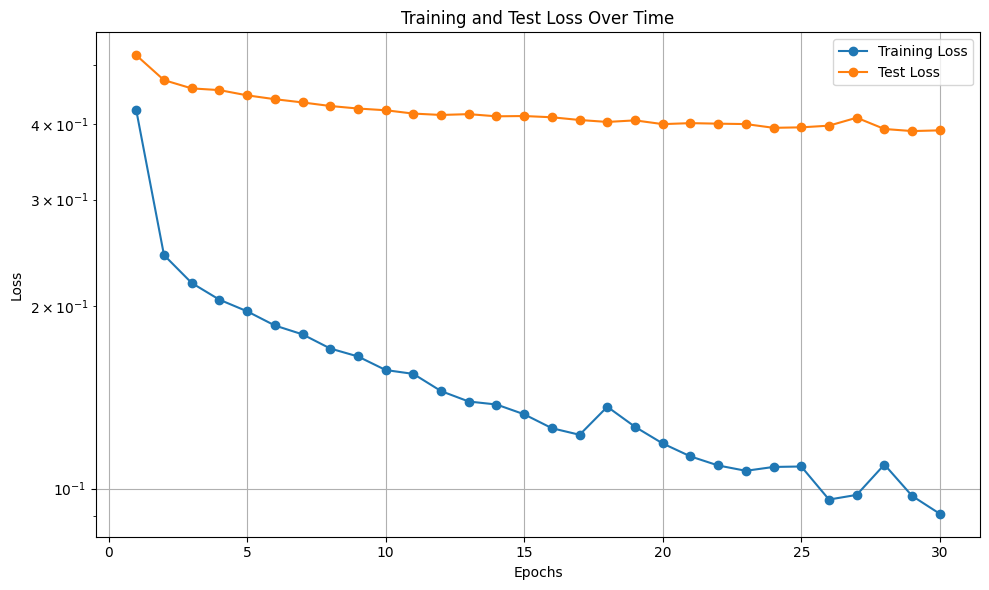

Optimal threshold: 0.216470, F1 score: 0.9194
Threshold used: 0.21646981

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99    119460
     Anomaly       0.93      0.91      0.92     12215

    accuracy                           0.99    131675
   macro avg       0.96      0.95      0.96    131675
weighted avg       0.99      0.99      0.99    131675

Accuracy: 0.9852667552686539
F1 Score: 0.9193883487077205
Precision: 0.9335077208674374
Recall: 0.9056897257470323
ROC-AUC: 0.9876571958175275


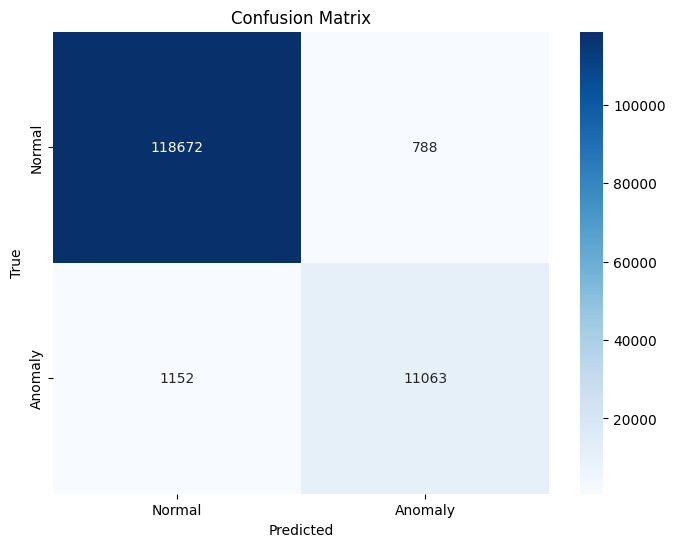


----- MISCLASSIFICATION ANALYSIS -----
Number of false negatives (missed attacks): 1152
Number of false positives (false alarms): 788

🚨 MISSED ATTACKS (False Negatives):

Attack type distribution in missed attacks:
Attack_Type
Benign&Bruteforce_benign        1042
DoS_DoS SYN Flood                 57
DoS_DoS-UDP_Flood                 27
DoS_DoS-HTTP_Flood                10
DDoS_DDoS ACK Fragmentation        9
DDoS_DDoS ICMP Flood               2
DDoS_DDoS-HTTP Flood               2
DDoS_DDoS-ICMP_Fragmentation       1
Mirai                              1
VulnerabilityScan                  1
Name: count, dtype: int64

Percentage of each attack type that was missed:
Benign&Bruteforce_benign: 0.26% missed (1042/398198)
DoS_DoS SYN Flood: 0.23% missed (57/24434)
DoS_DoS-UDP_Flood: 0.35% missed (27/7812)
DoS_DoS-HTTP_Flood: 0.43% missed (10/2331)
DDoS_DDoS ACK Fragmentation: 0.24% missed (9/3675)
DDoS_DDoS ICMP Flood: 0.66% missed (2/303)
DDoS_DDoS-HTTP Flood: 0.26% missed (2/758)
DDoS_DDo

In [ ]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

# Lists to store loss values for plotting
train_losses = []
test_losses = []

# Training loop
n_epochs = 30
model.train()
for epoch in range(n_epochs):
    # Training phase
    model.train()
    epoch_loss = 0
    for batch in train_loader:
        inputs = batch[0].to(device)

        if len(inputs.shape) == 2:
            inputs = inputs.unsqueeze(1)  # Add sequence dimension

        outputs, _= model(inputs)  # Get reconstructions, ignore encoded state
        loss = criterion(outputs, inputs)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)


# Evaluation phase - moved inside the epoch loop
    model.eval()
    with torch.no_grad():
        X_test_tensor_for_loss = X_test_tensor.to(device)

        if len(X_test_tensor_for_loss.shape) == 2:
            X_test_tensor_for_loss = X_test_tensor_for_loss.unsqueeze(1)  # Add sequence dimension

        outputs, _ = model(X_test_tensor_for_loss)
        test_loss = criterion(outputs, X_test_tensor_for_loss).item()
        test_losses.append(test_loss)

    scheduler.step(avg_train_loss)
    print(f"Epoch {epoch+1}/{n_epochs}, Train Loss: {avg_train_loss:.4f}, Test Loss: {test_loss:.4f}")

# Plot the training and test loss
plt.figure(figsize=(10, 6))
plt.plot(range(1, n_epochs + 1), train_losses, label='Training Loss', marker='o')
plt.plot(range(1, n_epochs + 1), test_losses, label='Test Loss', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Test Loss Over Time')
plt.legend()
plt.grid(True)
plt.yscale('log')  # Log scale can help visualize if losses are very small
plt.tight_layout()
plt.show()

# Continue with your anomaly detection evaluation as before
# Ensure y_test is a NumPy array
y_test_np = np.array(y_test)

model.eval()
with torch.no_grad():
    X_test_tensor = X_test_tensor.to(device)

    # Reshape for LSTM if necessary
    if len(X_test_tensor.shape) == 2:
        X_test_tensor = X_test_tensor.unsqueeze(1)  # Add sequence dimension

    reconstructions, _ = model(X_test_tensor)  # Get reconstructions

    # Calculate reconstruction error
    if len(X_test_tensor.shape) == 3:
        # For sequence data: mean across both sequence and features dimensions
        reconstruction_error = torch.mean((X_test_tensor - reconstructions) ** 2, dim=(1, 2)).cpu().numpy()
    else:
        # For non-sequence data
        reconstruction_error = torch.mean((X_test_tensor - reconstructions) ** 2, dim=1).cpu().numpy()

# Find optimal threshold
best_f1 = 0
best_threshold = 0

for percentile in range(0, 100):
    threshold = np.percentile(reconstruction_error, percentile)
    y_pred = (reconstruction_error > threshold).astype(int)
    f1 = f1_score(y_test_np, y_pred)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"Optimal threshold: {best_threshold:.6f}, F1 score: {best_f1:.4f}")


y_pred = (reconstruction_error > best_threshold).astype(int)

# Compute metrics
print("Threshold used:", best_threshold)
print("\nClassification Report:")
print(classification_report(y_test_np, y_pred, target_names=["Normal", "Anomaly"]))

print("Accuracy:", accuracy_score(y_test_np, y_pred))
print("F1 Score:", f1_score(y_test_np, y_pred))
print("Precision:", precision_score(y_test_np, y_pred))
print("Recall:", recall_score(y_test_np, y_pred))
print("ROC-AUC:", roc_auc_score(y_test_np, reconstruction_error))  # continuous error values

# Confusion matrix
cm = confusion_matrix(y_test_np, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Anomaly"],
            yticklabels=["Normal", "Anomaly"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


X_indices = np.arange(len(X_scaled))
_, test_indices = train_test_split(
    X_indices, test_size=0.3, random_state=42, stratify=df_temp['stratify_col'])


false_negatives = (y_test == 1) & (y_pred == 0)  
false_positives = (y_test == 0) & (y_pred == 1)  


fn_indices = test_indices[false_negatives]
fp_indices = test_indices[false_positives]

print("\n----- MISCLASSIFICATION ANALYSIS -----")
print(f"Number of false negatives (missed attacks): {np.sum(false_negatives)}")
print(f"Number of false positives (false alarms): {np.sum(false_positives)}")


if len(fn_indices) > 0:
    missed_attacks_df = df.iloc[fn_indices]
    
   
    actual_missed_attacks = missed_attacks_df[missed_attacks_df['Anomaly_Label'] == 'Attack']
    
    print("\n🚨 MISSED ATTACKS (False Negatives):")
    print(f"Total missed detections: {len(missed_attacks_df)}")
    print(f"Actual attacks missed: {len(actual_missed_attacks)}")
    
    if len(actual_missed_attacks) > 0:
        
        print("\nAttack type distribution in missed attacks (actual attacks only):")
        attack_type_counts = actual_missed_attacks['Attack_Types'].value_counts()
        print(attack_type_counts)

       
        print("\nPercentage of each attack type that was missed:")
        for attack_type in attack_type_counts.index:
           
            total_of_type = df[(df['Attack_Types'] == attack_type) & 
                              (df['Anomaly_Label'] == 'Attack')].shape[0]
            missed_of_type = attack_type_counts[attack_type]
            missed_percent = (missed_of_type / total_of_type) * 100
            print(f"{attack_type}: {missed_percent:.2f}% missed ({missed_of_type}/{total_of_type})")
        
    
        print(f"\nFirst 5 examples of missed attacks:")
        print(actual_missed_attacks[['Attack_Types', 'Anomaly_Label']].head())
    else:
        print("No actual attacks were missed - all false negatives were benign data.")


if len(fp_indices) > 0:
    false_alarms_df = df.iloc[fp_indices]
    

    actual_false_alarms = false_alarms_df[false_alarms_df['Anomaly_Label'] == 'Normal']
    
    print("\n⚠️  FALSE ALARMS (False Positives):")
    print(f"Total false alarms: {len(false_alarms_df)}")
    print(f"Actual normal data flagged as attacks: {len(actual_false_alarms)}")
    
    if len(actual_false_alarms) > 0:

        print("\nTypes of normal data incorrectly flagged as attacks:")
        normal_type_counts = actual_false_alarms['Attack_Types'].value_counts()
        print(normal_type_counts)
        



print("\n----- PERFORMANCE BY ATTACK TYPE -----")
test_df = df.iloc[test_indices].copy()
test_df['predicted'] = y_pred
test_df['actual'] = y_test


attack_types_in_test = test_df[test_df['Anomaly_Label'] == 'Attack']['Attack_Types'].unique()

print("Detection rate by attack type:")
for attack_type in attack_types_in_test:
    attack_subset = test_df[(test_df['Attack_Types'] == attack_type) & 
                           (test_df['Anomaly_Label'] == 'Attack')]
    
    if len(attack_subset) > 0:
        total_attacks = len(attack_subset)
        detected_attacks = np.sum(attack_subset['predicted'] == 1)
        detection_rate = (detected_attacks / total_attacks) * 100
        
        print(f"{attack_type}: {detection_rate:.2f}% detected ({detected_attacks}/{total_attacks})")


In [ ]:
false_negatives = (y_test == 1) & (y_pred == 0)  # Missed attacks
false_positives = (y_test == 0) & (y_pred == 1)  # False alarms


fn_indices = test_indices[false_negatives]
fp_indices = test_indices[false_positives]

print("\n----- MISCLASSIFICATION ANALYSIS -----")
print(f"Number of false negatives (missed attacks): {np.sum(false_negatives)}")
print(f"Number of false positives (false alarms): {np.sum(false_positives)}")


if len(fn_indices) > 0:
    missed_attacks_df = df.iloc[fn_indices]
    
    
    actual_missed_attacks = missed_attacks_df[missed_attacks_df['Anomaly_Label'] == 'Attack']
    
    if len(actual_missed_attacks) > 0:
        
        attack_type_counts_missed = actual_missed_attacks['Attack_Type'].value_counts()
        print("\n----- TRAIN SET ANALYSIS -----") 
        
       
        detection_rates_missed_analysis = []
        for attack_type in attack_type_counts_missed.index:
            
            total_of_type = df[(df['Attack_Type'] == attack_type) & 
                               (df['Anomaly_Label'] == 'Attack')].shape[0]
            missed_of_type = attack_type_counts_missed[attack_type]
            detected_of_type = total_of_type - missed_of_type
            
     
            if total_of_type > 0:
                detection_percent = (detected_of_type / total_of_type) * 100
            else:
                detection_percent = 0.0
            
            detection_rates_missed_analysis.append((attack_type, detection_percent, detected_of_type, total_of_type))
        
     
        detection_rates_missed_analysis.sort(key=lambda x: x[1], reverse=True)
        
        print("\nDetection rate of each attack type (sorted from highest to lowest):")
   
        for attack_type, detection_percent, detected_of_type, total_of_type in detection_rates_missed_analysis:
            print(f"{attack_type}: {detection_percent:.2f}% detected ({detected_of_type}/{total_of_type})")
    

print("\n----- TEST SET ANALYSIS -----")
test_df = df.iloc[test_indices].copy()
test_df['predicted'] = y_pred
test_df['actual'] = y_test


attack_types_in_test = test_df[test_df['Anomaly_Label'] == 'Attack']['Attack_Type'].unique()

print("\nDetection rate by attack type (sorted from highest to lowest):")


detection_rates_test_analysis = []
for attack_type in attack_types_in_test:
    attack_subset = test_df[(test_df['Attack_Type'] == attack_type) & 
                            (test_df['Anomaly_Label'] == 'Attack')]
    
    if len(attack_subset) > 0:
        total_attacks = len(attack_subset)
        detected_attacks = np.sum(attack_subset['predicted'] == 1)
        detection_rate = (detected_attacks / total_attacks) * 100
        detection_rates_test_analysis.append((attack_type, detection_rate, detected_attacks, total_attacks))


detection_rates_test_analysis.sort(key=lambda x: x[1], reverse=True)


for attack_type, detection_rate, detected_attacks, total_attacks in detection_rates_test_analysis:
    print(f"{attack_type}: {detection_rate:.2f}% detected ({detected_attacks}/{total_attacks})")



----- MISCLASSIFICATION ANALYSIS -----
Number of false negatives (missed attacks): 1152
Number of false positives (false alarms): 788

----- TRAIN SET ANALYSIS -----

Detection rate of each attack type (sorted from highest to lowest):
DoS_DoS SYN Flood: 99.94% detected (24420/24434)
Mirai: 99.24% detected (260/262)
DoS_DoS-HTTP_Flood: 98.58% detected (2298/2331)
DoS_DoS-UDP_Flood: 95.58% detected (7467/7812)
DDoS_DDoS ACK Fragmentation: 95.51% detected (3510/3675)
DDoS_DDoS-HTTP Flood: 75.86% detected (575/758)
DDoS_DDoS ICMP Flood: 75.58% detected (229/303)
DDoS_DDoS-ICMP_Fragmentation: 71.10% detected (342/481)
VulnerabilityScan: 70.20% detected (464/661)

----- TEST SET ANALYSIS -----

Detection rate by attack type (sorted from highest to lowest):
DoS_DoS SYN Flood: 99.81% detected (7316/7330)
Mirai: 97.47% detected (77/79)
DoS_DoS-HTTP_Flood: 95.28% detected (666/699)
DoS_DoS-UDP_Flood: 85.28% detected (1999/2344)
DDoS_DDoS ACK Fragmentation: 85.04% detected (938/1103)
DDoS_DDoS-H